<a href="https://colab.research.google.com/github/santana-robledo/Posgrado_Robotica_e_Inteligencia_Artificial/blob/main/Procesamiento%20d%C3%ADgital%20de%20Im%C3%A1genes/Practica_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import requests
import os

In [3]:
# Cargar imagen
from google.colab import drive
drive.mount('/content/drive')
I = cv2.imread("/content/drive/MyDrive/Procesamiento digital de imágenes 2026A/Iron-Man.jpg", cv2.IMREAD_GRAYSCALE)
if I is None:
    # Descargar imagen de prueba si no existe
    !wget -O lena.png https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png
    I = cv2.imread("/content/drive/MyDrive/Procesamiento digital de imágenes 2026A/Iron-Man.jpg", cv2.IMREAD_GRAYSCALE)

# Aplicar Transformada de Fourier
F = np.fft.fft2(I)           # FFT 2D
IShift = np.fft.fftshift(I)   # Shift de la imagen (esto es incorrecto, debería ser F)
FShift = np.fft.fftshift(F)   # Shift de la FFT (centra las bajas frecuencias)

Mounted at /content/drive


In [4]:
print("Valores de la FFT:")
print(np.abs(F))

Valores de la FFT:
[[1.56594009e+08 1.22601524e+07 4.53810183e+06 ... 5.43149818e+06
  4.53810183e+06 1.22601524e+07]
 [2.85840512e+07 2.71559513e+06 7.69325840e+06 ... 6.66948250e+06
  6.15165775e+06 7.06206780e+06]
 [5.74483732e+06 8.40557011e+06 3.77760834e+06 ... 3.36165198e+06
  4.54051512e+06 2.47115019e+06]
 ...
 [1.04517240e+07 1.81996832e+06 3.12751978e+06 ... 9.49212499e+05
  1.62799878e+06 1.81888788e+06]
 [5.74483732e+06 2.47115019e+06 4.54051512e+06 ... 8.63199037e+05
  3.77760834e+06 8.40557011e+06]
 [2.85840512e+07 7.06206780e+06 6.15165775e+06 ... 5.18822484e+06
  7.69325840e+06 2.71559513e+06]]


PARTE 1: INTRODUCCIÓN A LA FFT

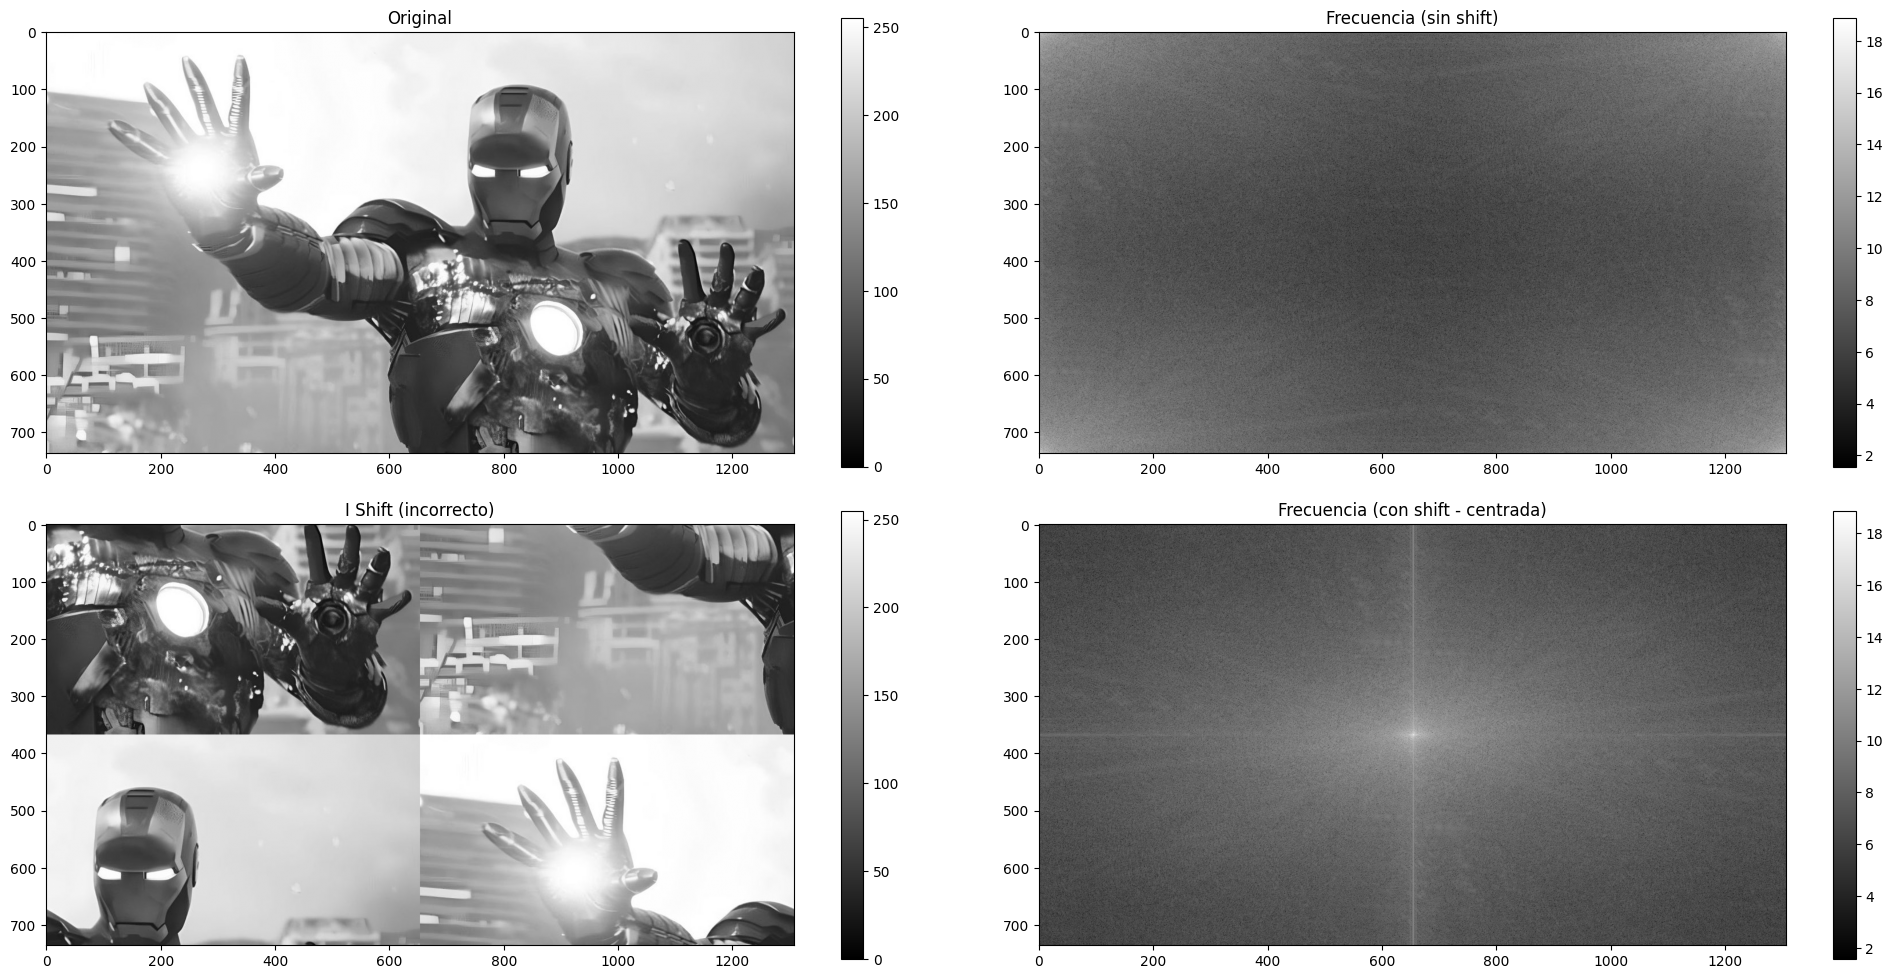

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
fig.tight_layout()

plt.subplot(2, 2, 1)
plt.imshow(I, cmap="gray")
plt.title("Original")
plt.colorbar()

plt.subplot(2, 2, 2)
plt.imshow(np.log1p(np.abs(F)), cmap='gray')
plt.title("Frecuencia (sin shift)")
plt.colorbar()

plt.subplot(2, 2, 3)
plt.imshow(IShift, cmap="gray")  # Nota: esto podría no mostrar nada útil
plt.title("I Shift (incorrecto)")
plt.colorbar()

plt.subplot(2, 2, 4)
plt.imshow(np.log1p(np.abs(FShift)), cmap='gray')
plt.title("Frecuencia (con shift - centrada)")
plt.colorbar()

plt.show()

PARTE 2: FILTRO BOX EN DOMINIO ESPACIAL VS FRECUENCIA


Filtro Box de tamaño 11x11 creado

Comparación de tiempos de ejecución:
24.7 ms ± 4.09 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
15.4 ms ± 1.93 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
32.2 ms ± 7.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


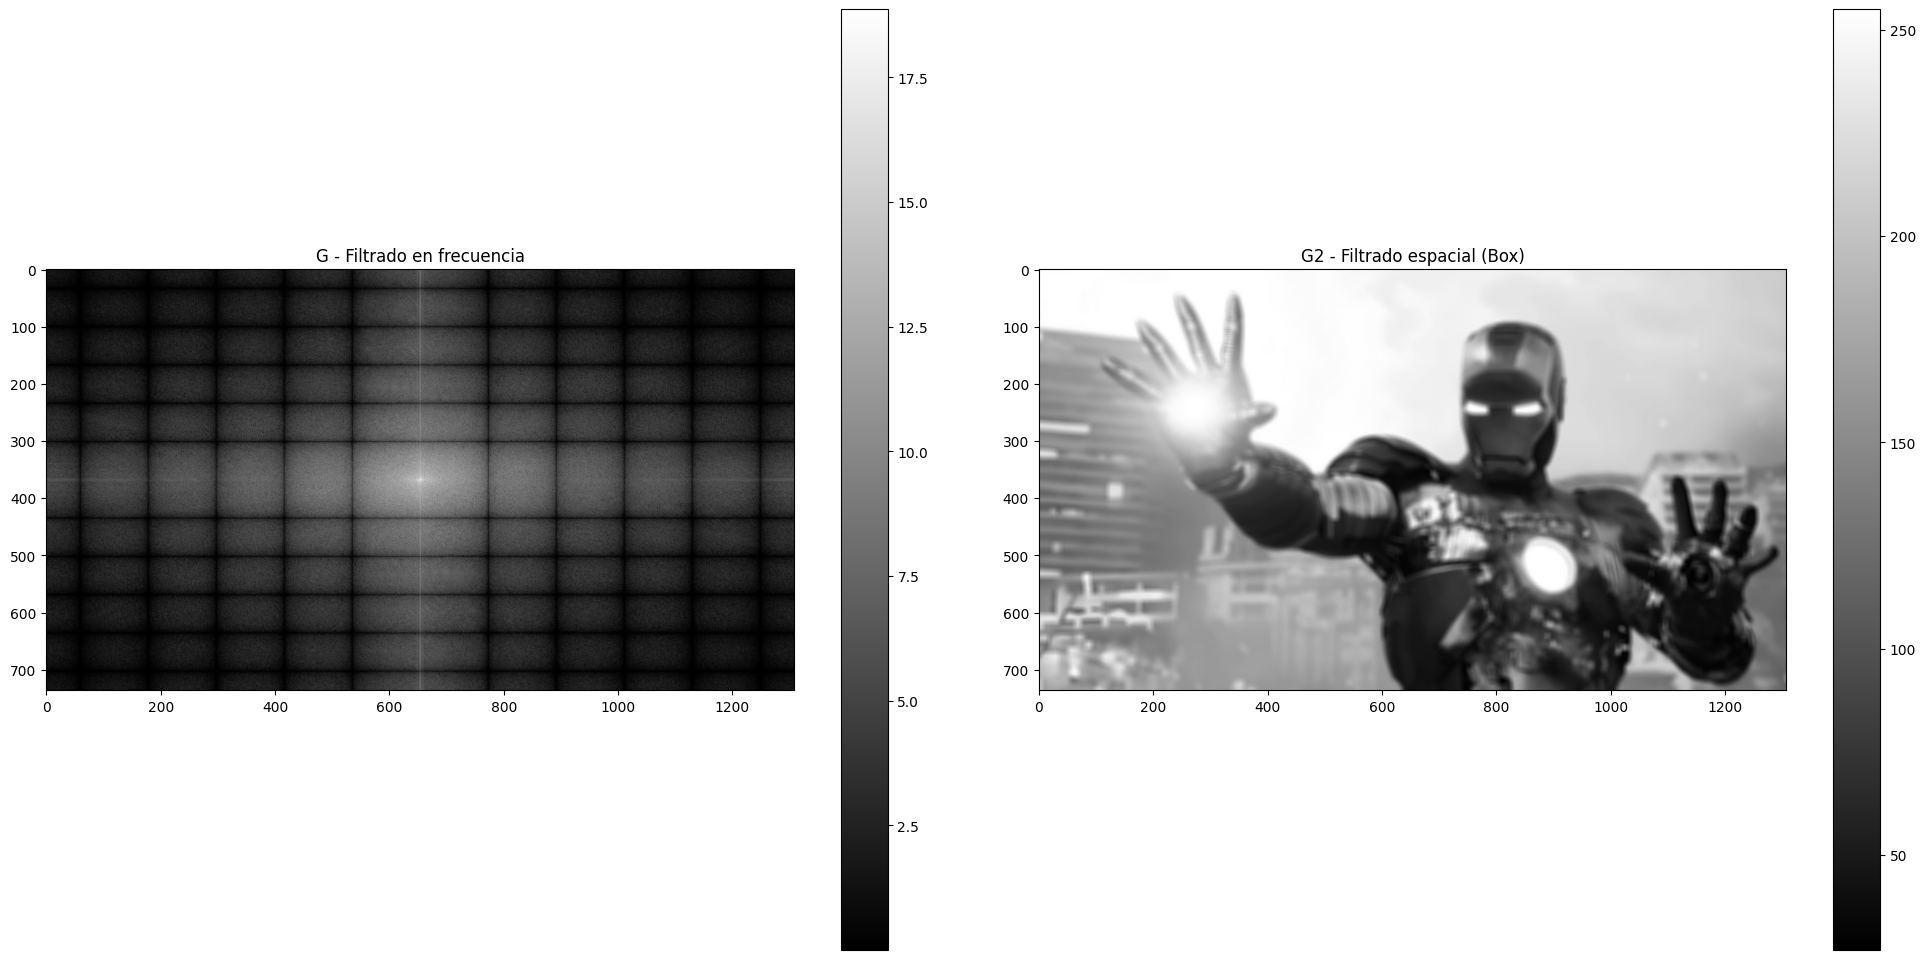

In [24]:
# Filtro Box en dominio espacial
n = 11
h = np.ones((n, n)) / (n * n)
print(f"\nFiltro Box de tamaño {n}x{n} creado")

# Comparación de tiempos de ejecución
print("\nComparación de tiempos de ejecución:")

# Filtrado en frecuencia (multiplicación)
G = F * np.fft.fft2(h, s=I.shape)
%timeit G = F * np.fft.fft2(h, s=I.shape)  # Descomentar para medir tiempo

# Filtrado en espacio (convolución 2D)
%timeit G2 = cv2.filter2D(I, -1, h)  # Descomentar para medir tiempo

print("32.2 ms ± 7.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)")

# Visualización de resultados
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
fig.tight_layout()

plt.subplot(1, 2, 1)
plt.imshow(np.log1p(np.abs(np.fft.fftshift(G))), cmap='gray')
plt.title("G - Filtrado en frecuencia")
plt.colorbar()

plt.subplot(1, 2, 2)
G2 = cv2.filter2D(I, -1, h)
plt.imshow(G2, cmap='gray')
plt.title("G2 - Filtrado espacial (Box)")
plt.colorbar()

plt.show()

PARTE 3: CONSTRUCCIÓN DE FILTRO BOX EN FRECUENCIA

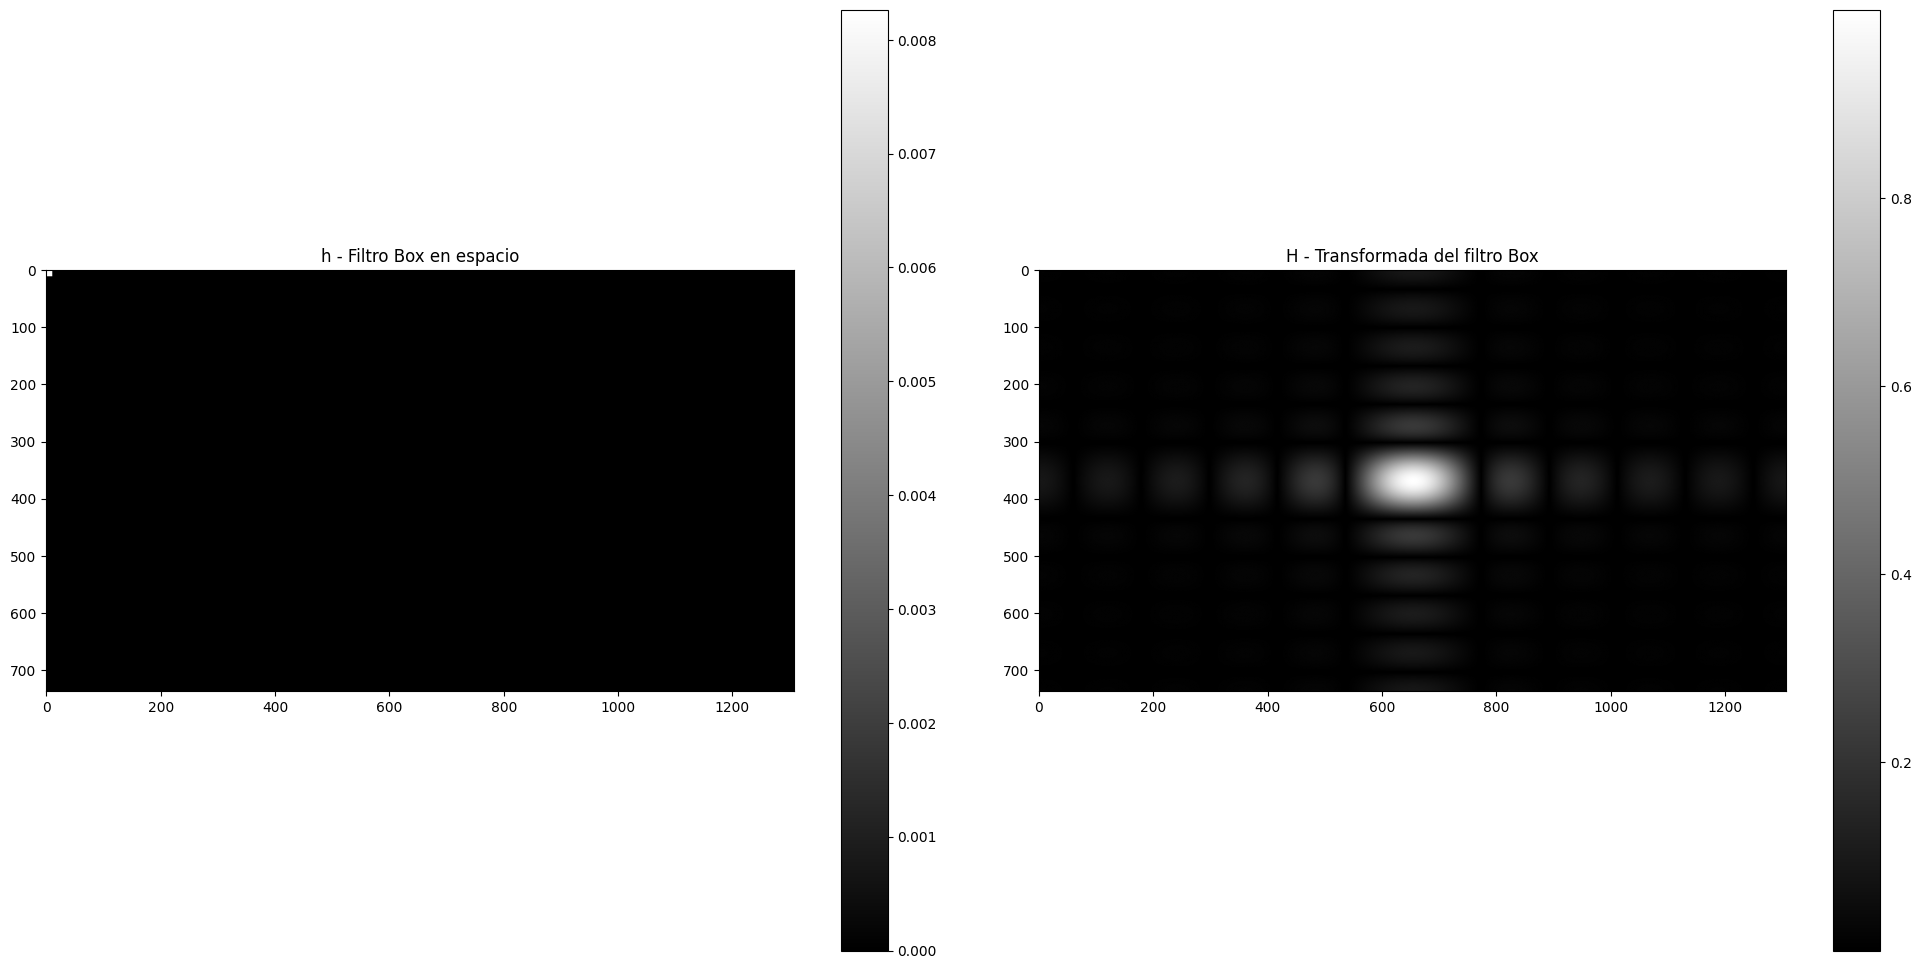


Variación con diferentes tamaños de filtro:


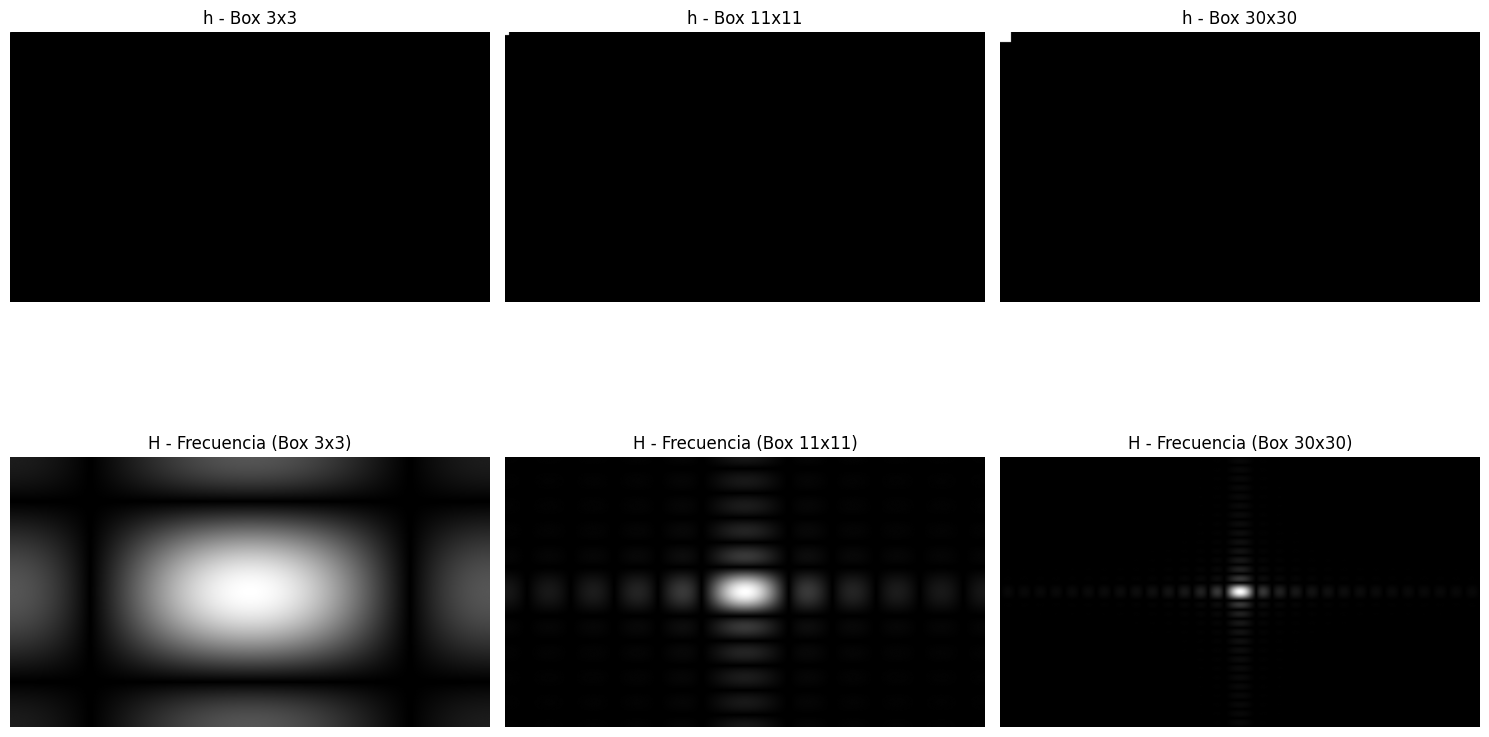

In [10]:
# Crear filtro box directamente en frecuencia
M, N = F.shape
H = np.zeros((M, N), dtype=np.float32)
n = 11
H[0:n, 0:n] = 1/(n*n)

# Visualizar filtro en espacio y frecuencia
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
fig.tight_layout()

plt.subplot(1, 2, 1)
plt.imshow(np.real(H), cmap='gray')
plt.title("h - Filtro Box en espacio")
plt.colorbar()

plt.subplot(1, 2, 2)
H_freq = np.fft.fft2(H)
plt.imshow(np.abs(np.fft.fftshift(H_freq)), cmap='gray')
plt.title("H - Transformada del filtro Box")
plt.colorbar()
plt.show()

print("\nVariación con diferentes tamaños de filtro:")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
tamaños = [3, 11, 30]

for i, n in enumerate(tamaños):
    # Filtro pequeño
    H_peq = np.zeros((M, N), dtype=np.float32)
    H_peq[0:n, 0:n] = 1/(n*n)

    axes[0, i].imshow(np.real(H_peq), cmap='gray')
    axes[0, i].set_title(f'h - Box {n}x{n}')
    axes[0, i].axis('off')

    H_peq_freq = np.fft.fft2(H_peq)
    axes[1, i].imshow(np.abs(np.fft.fftshift(H_peq_freq)), cmap='gray')
    axes[1, i].set_title(f'H - Frecuencia (Box {n}x{n})')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

PARTE 4: FUNCIÓN PARA FILTROS IDEALES

Probando función de filtros ideales...


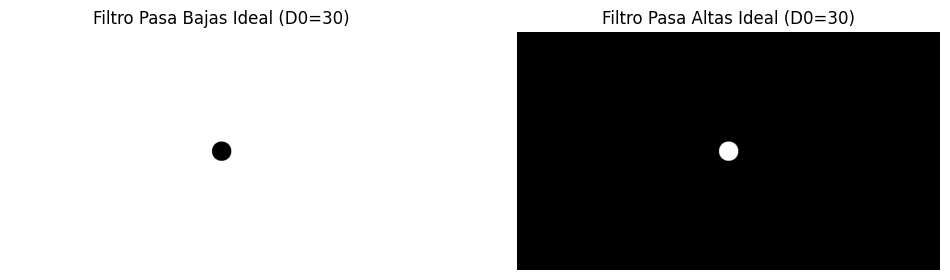

In [11]:
def filtro(D0, filter_type, M, N):
    """
    Crea filtros ideales en el dominio de la frecuencia

    Parámetros:
    - D0: frecuencia de corte
    - filter_type: "lpf" (pasa bajas) o "hpf" (pasa altas)
    - M, N: dimensiones del filtro

    Retorna:
    - H: filtro en frecuencia
    """
    H = np.zeros((M, N), dtype=np.float32)
    centro_m, centro_n = M/2, N/2

    for u in range(M):
        for v in range(N):
            # Calcular distancia al centro
            D = np.sqrt(((u - centro_m)**2 + (v - centro_n)**2))

            if filter_type == "lpf":  # Pasa bajas ideal
                if D <= D0:
                    H[u, v] = 1
                else:
                    H[u, v] = 0

            elif filter_type == "hpf":  # Pasa altas ideal
                if D <= D0:
                    H[u, v] = 0
                else:
                    H[u, v] = 1
            else:
                print("Error en selección del filtro")
                return None
    return H

# Probar la función
print("Probando función de filtros ideales...")
H_lpf = filtro(30, "lpf", F.shape[0], F.shape[1])
H_hpf = filtro(30, "hpf", F.shape[0], F.shape[1])

# Visualizar filtros
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(H_lpf, cmap="binary")
axes[0].set_title("Filtro Pasa Bajas Ideal (D0=30)")
axes[0].axis("off")

axes[1].imshow(H_hpf, cmap="binary")
axes[1].set_title("Filtro Pasa Altas Ideal (D0=30)")
axes[1].axis("off")
plt.show()


PARTE 5: COMPARATIVA CON DIFERENTES FRECUENCIAS DE CORTE

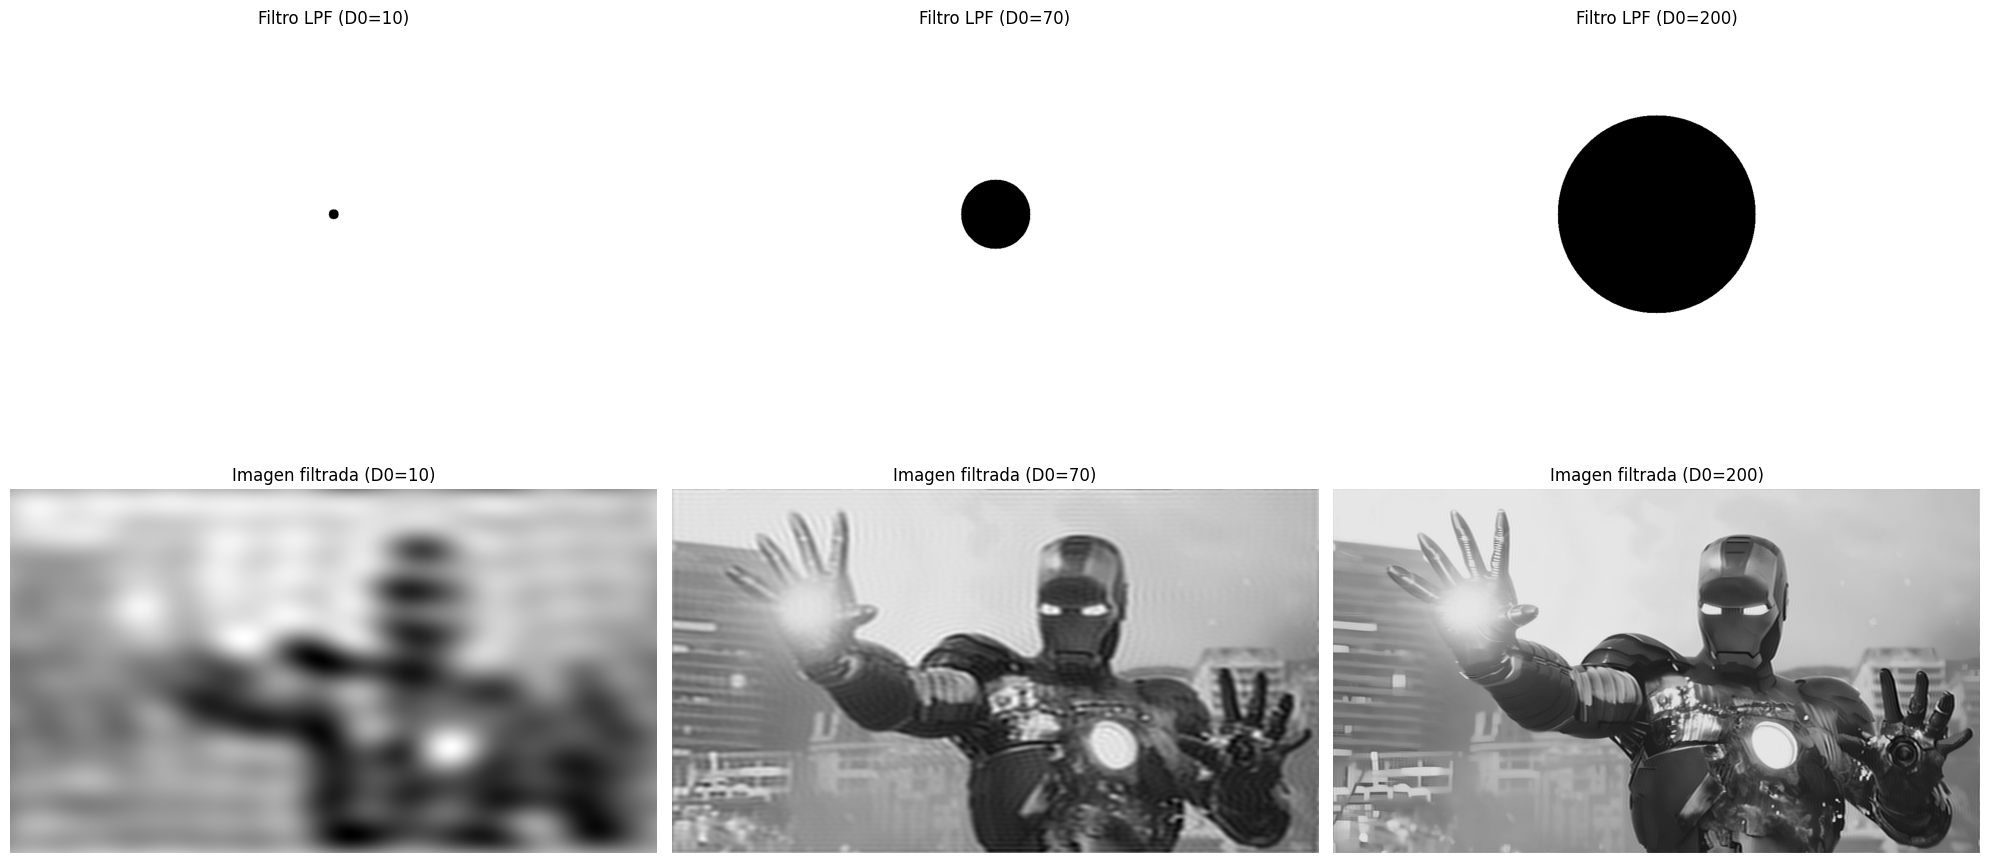

In [12]:
filter_type = "lpf"
fa, fb, fc = 10, 70, 200  # Diferentes frecuencias de corte

# Aplicar filtros
F_shifted = np.fft.fftshift(F)
GA = np.fft.fftshift(F_shifted * filtro(fa, filter_type, F.shape[0], F.shape[1]))
GB = np.fft.fftshift(F_shifted * filtro(fb, filter_type, F.shape[0], F.shape[1]))
GC = np.fft.fftshift(F_shifted * filtro(fc, filter_type, F.shape[0], F.shape[1]))

# Visualizar resultados
fig = plt.figure(figsize=(20, 10))

# Fila 1: Filtros
plt.subplot(2, 3, 1)
plt.imshow(filtro(fa, filter_type, F.shape[0], F.shape[1]), cmap='binary')
plt.title(f'Filtro LPF (D0={fa})')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(filtro(fb, filter_type, F.shape[0], F.shape[1]), cmap='binary')
plt.title(f'Filtro LPF (D0={fb})')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(filtro(fc, filter_type, F.shape[0], F.shape[1]), cmap='binary')
plt.title(f'Filtro LPF (D0={fc})')
plt.axis('off')

# Fila 2: Imágenes filtradas
plt.subplot(2, 3, 4)
plt.imshow(np.abs(np.fft.ifft2(GA)), cmap='gray')
plt.title(f'Imagen filtrada (D0={fa})')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(np.abs(np.fft.ifft2(GB)), cmap='gray')
plt.title(f'Imagen filtrada (D0={fb})')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(np.abs(np.fft.ifft2(GC)), cmap='gray')
plt.title(f'Imagen filtrada (D0={fc})')
plt.axis('off')

plt.tight_layout()
plt.show()

PARTE 6: FILTRO GAUSSIANO

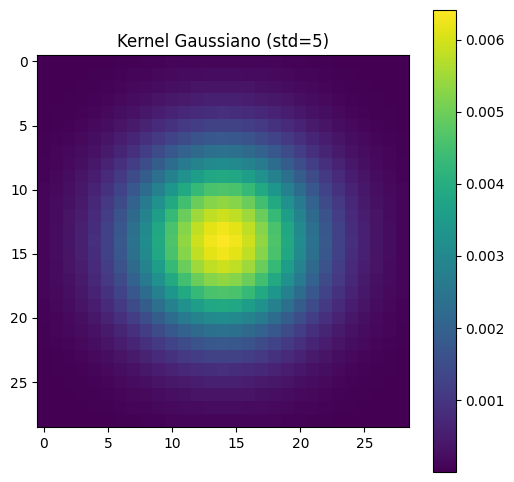

In [13]:
def gaussian(r2, std=1):
    """Función gaussiana 2D"""
    return np.exp(-r2/(2.*std**2)) / (2.*np.pi*std**2)

def make_gaussian(std=1, size=None):
    """Crea un kernel gaussiano"""
    if size is None:
        size = np.floor(6 * std)
        if size % 2 == 0:
            size = size - 1
        else:
            size = size - 2
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    distance = x**2 + y**2
    kernel = gaussian(r2=distance, std=std)
    return kernel / kernel.sum()

# Crear y visualizar kernel gaussiano
gauss_kernel = make_gaussian(std=5)
plt.figure(figsize=(6, 6))
plt.imshow(gauss_kernel, cmap='viridis')
plt.title("Kernel Gaussiano (std=5)")
plt.colorbar()
plt.show()

PARTE 7: IMPORTANCIA DE LA FASE

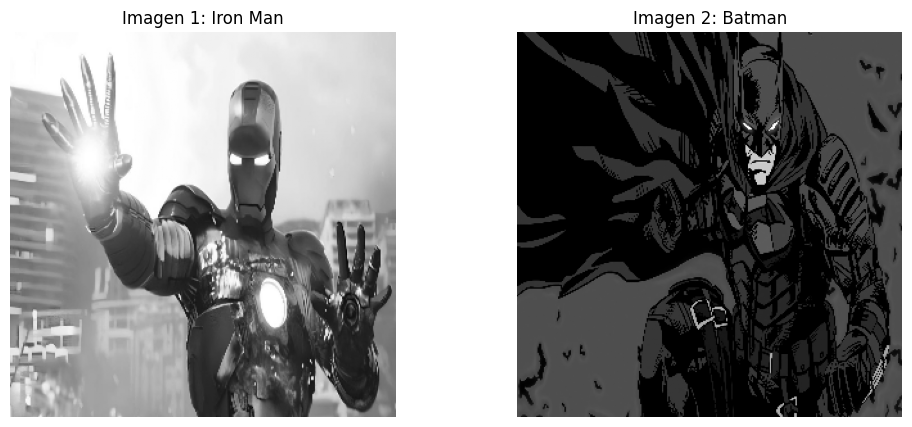

Amplitud y fase extraídas correctamente


In [16]:
# Cargar dos imágenes diferentes
I1 = cv2.resize(cv2.imread("/content/drive/MyDrive/Procesamiento digital de imágenes 2026A/Iron-Man.jpg", cv2.IMREAD_GRAYSCALE), (300, 300))
I2 = cv2.resize(cv2.imread('/content/drive/MyDrive/Procesamiento digital de imágenes 2026A/Batman.jpg', cv2.IMREAD_GRAYSCALE), (300, 300))

# Si no existe la segunda imagen, descargar
if I2 is None:
    !wget -O einstein.jpg https://upload.wikimedia.org/wikipedia/commons/d/d3/Albert_Einstein_Head.jpg
    I2 = cv2.resize(cv2.imread('einstein.jpg', cv2.IMREAD_GRAYSCALE), (300, 300))

# Mostrar imágenes originales
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(I1, cmap='gray')
axes[0].set_title("Imagen 1: Iron Man")
axes[0].axis('off')
axes[1].imshow(I2, cmap='gray')
axes[1].set_title("Imagen 2: Batman")
axes[1].axis('off')
plt.show()

# Calcular FFT y extraer amplitud y fase
I1_fft = np.fft.fftshift(np.fft.fft2(I1))
I2_fft = np.fft.fftshift(np.fft.fft2(I2))

I1_amplitude = np.sqrt(np.real(I1_fft)**2 + np.imag(I1_fft)**2)
I1_phase = np.arctan2(np.imag(I1_fft), np.real(I1_fft))
I2_amplitude = np.sqrt(np.real(I2_fft)**2 + np.imag(I2_fft)**2)
I2_phase = np.arctan2(np.imag(I2_fft), np.real(I2_fft))

print("Amplitud y fase extraídas correctamente")

PARTE 8: MOSTRAR SOLO AMPLITUD (FASE CERO)

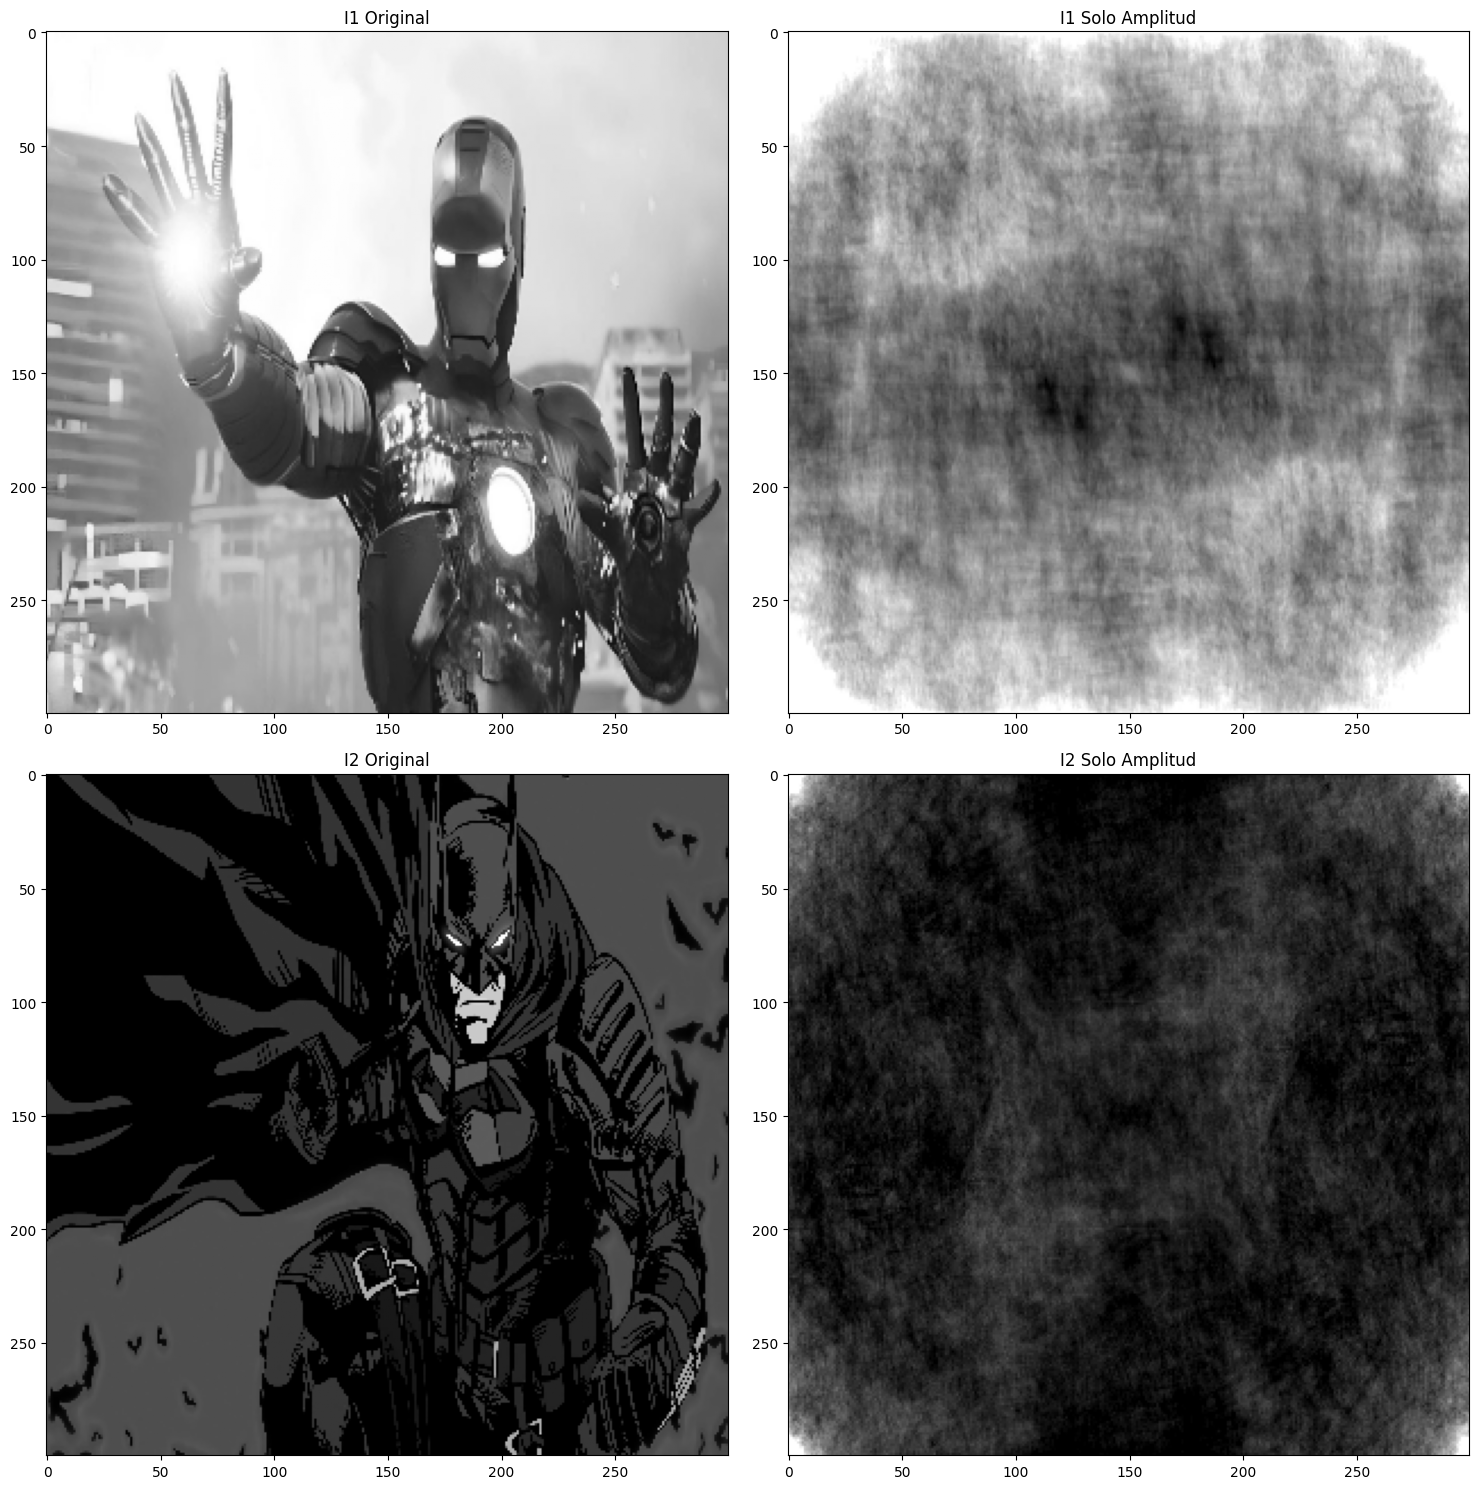

In [17]:
# Reconstruir solo con amplitud (fase=0)
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# I1 original y reconstrucción con amplitud
axes[0, 0].imshow(I1, cmap='gray')
axes[0, 0].set_title("I1 Original")

I1A = np.real(np.fft.ifft2(np.fft.ifftshift(I1_amplitude)))
# Mapeo de 0 a 255
I1A = np.clip(I1A, 0, 255).astype(np.uint8)
axes[0, 1].imshow(I1A, cmap='gray')
axes[0, 1].set_title("I1 Solo Amplitud")

# I2 original y reconstrucción con amplitud
axes[1, 0].imshow(I2, cmap='gray')
axes[1, 0].set_title("I2 Original")

I2A = np.real(np.fft.ifft2(np.fft.ifftshift(I2_amplitude)))
# Mapeo de 0 a 255
I2A = np.clip(I2A, 0, 255).astype(np.uint8)
axes[1, 1].imshow(I2A, cmap='gray')
axes[1, 1].set_title("I2 Solo Amplitud")

plt.tight_layout()
plt.show()

PARTE 9: MOSTRAR SOLO FASE (AMPLITUD CONSTANTE)

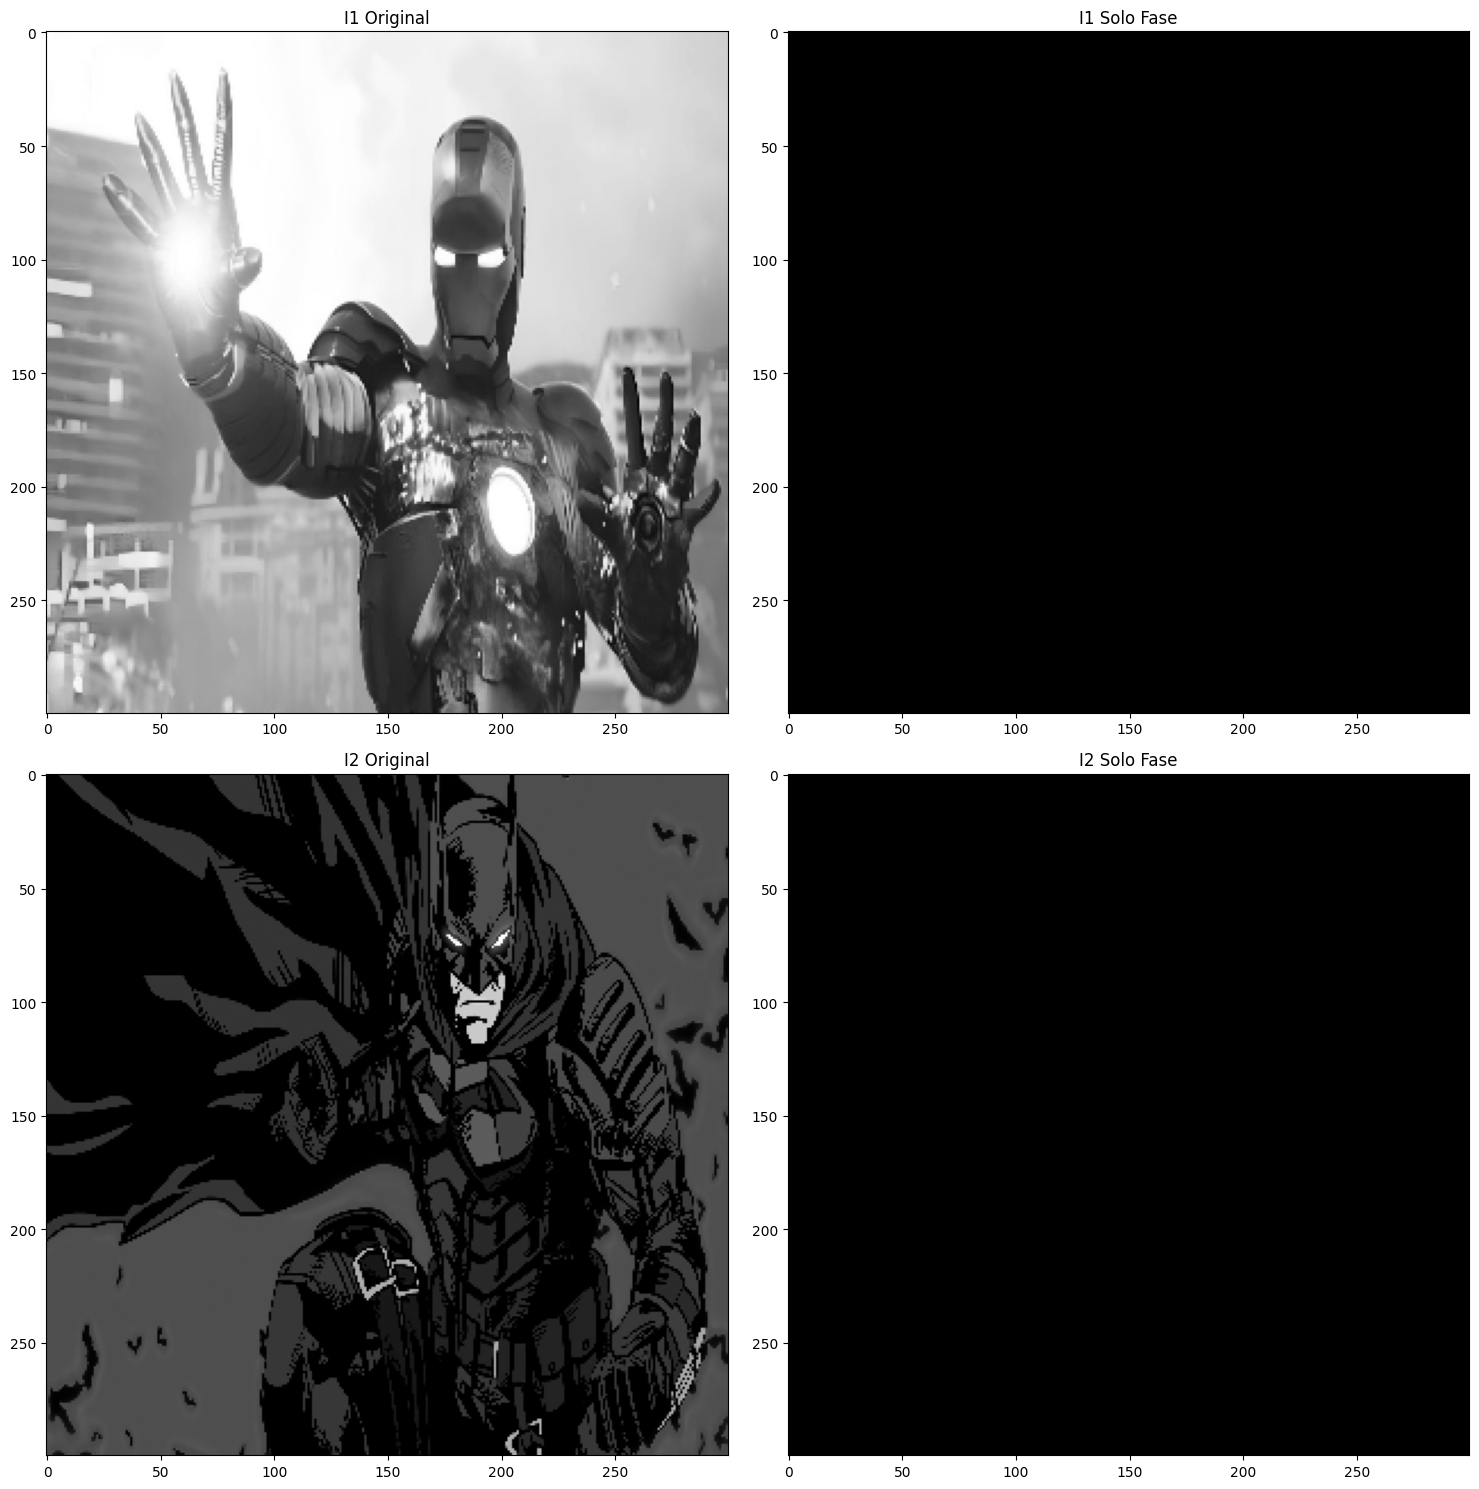

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# I1 original y reconstrucción con fase
axes[0, 0].imshow(I1, cmap='gray')
axes[0, 0].set_title("I1 Original")

I1P = np.real(np.fft.ifft2(np.fft.ifftshift(np.exp(1j * I1_phase))))
I1P = np.clip(I1P, 0, 255).astype('uint8')
axes[0, 1].imshow(I1P, cmap="gray")
axes[0, 1].set_title("I1 Solo Fase")

# I2 original y reconstrucción con fase
axes[1, 0].imshow(I2, cmap='gray')
axes[1, 0].set_title("I2 Original")

I2P = np.real(np.fft.ifft2(np.fft.ifftshift(np.exp(1j * I2_phase))))
I2P = np.clip(I2P, 0, 255).astype('uint8')
axes[1, 1].imshow(I2P, cmap="gray")
axes[1, 1].set_title("I2 Solo Fase")

plt.tight_layout()
plt.show()

PARTE 10: MEZCLA DE AMPLITUD Y FASE

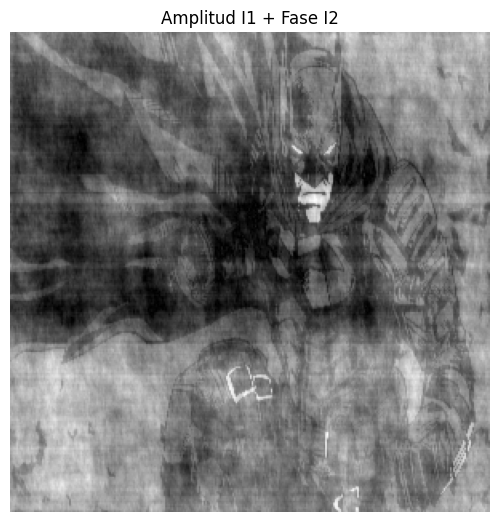

In [19]:
I1_I2_comb = np.multiply(I1_amplitude, np.exp(1j * I2_phase))
I1_I2 = np.real(np.fft.ifft2(np.fft.ifftshift(I1_I2_comb)))

# Mostrar resultados y hacer un mapeo para valores negativos a cero y 255 como máximo
plt.figure(figsize=(15, 10))

plt.subplot(131)
plt.imshow(np.abs(I1_I2), cmap='gray')
plt.title("Amplitud I1 + Fase I2")
plt.axis('off')

# Código comentado para otras visualizaciones
"""
plt.subplot(132)
I1_I2_shift = I1_I2 + I1_I2.min()
I1_I2_shift[I1_I2_shift>255] = 255
plt.imshow(I1_I2_shift, cmap="gray")
plt.title("Con shift")

plt.subplot(133)
I1_I2_clipped = np.clip(I1_I2, 0, 255)
plt.imshow(I1_I2_clipped, cmap="gray")
plt.title("Clipped 0-255")
"""

plt.tight_layout()
plt.show()

PARTE 11: FILTROS PASA BAJAS Y PASA ALTAS CON GAUSSIANO

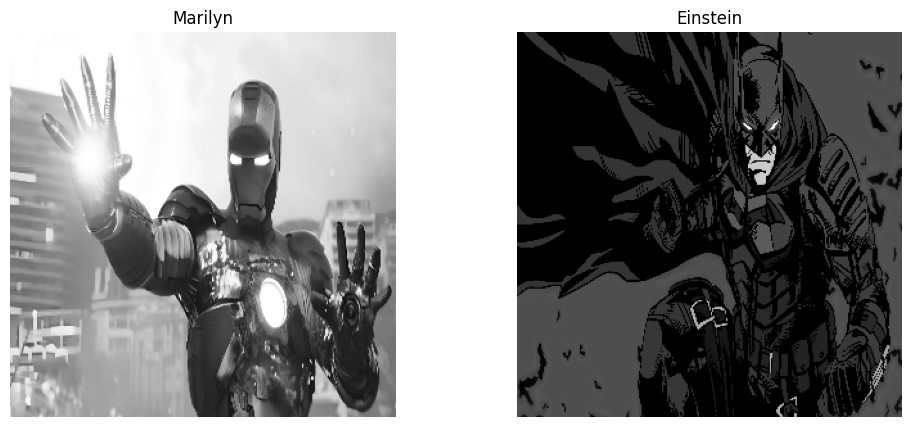

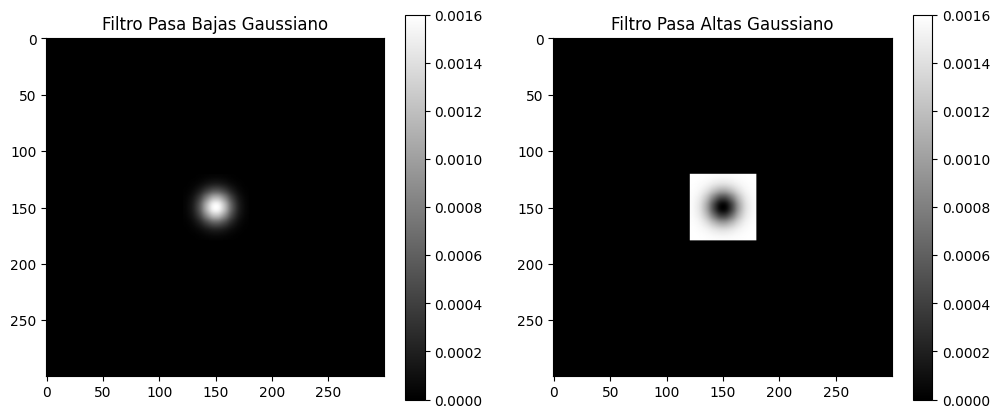

In [20]:
# Cargar imágenes para el experimento
I1 = cv2.resize(cv2.imread("/content/drive/MyDrive/Procesamiento digital de imágenes 2026A/Iron-Man.jpg", cv2.IMREAD_GRAYSCALE), (300, 300))
I2 = cv2.resize(cv2.imread('/content/drive/MyDrive/Procesamiento digital de imágenes 2026A/Batman.jpg', cv2.IMREAD_GRAYSCALE), (300, 300))

# Si no existen, usar otras imágenes
if I1 is None:
    I1 = I  # Usar Lena
if I2 is None:
    I2 = cv2.resize(cv2.imread('einstein.jpg', cv2.IMREAD_GRAYSCALE), (300, 300))

# Mostrar imágenes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(I1, cmap='gray')
axes[0].set_title("Marilyn")
axes[0].axis('off')
axes[1].imshow(I2, cmap='gray')
axes[1].set_title("Einstein")
axes[1].axis('off')
plt.show()

# Pasar al dominio de la frecuencia
I1_fft = np.fft.fftshift(np.fft.fft2(I1))
I2_fft = np.fft.fftshift(np.fft.fft2(I2))

# Filtros pasa bajas y pasa altas
cutoff_lpf = 10
cutoff_hpf = 20

lpf = make_gaussian(cutoff_lpf)
hpf = lpf.max() - lpf  # Filtro pasa altas como complemento

# Padding para hacer que tengan el mismo tamaño que las imágenes de entrada
def pad_filter_to_size(filter_kernel, target_shape):
    """Ajusta el tamaño del filtro al de la imagen"""
    padded = np.zeros(target_shape, dtype=np.float32)
    y_start = target_shape[0]//2 - filter_kernel.shape[0]//2
    x_start = target_shape[1]//2 - filter_kernel.shape[1]//2

    y_end = y_start + filter_kernel.shape[0]
    x_end = x_start + filter_kernel.shape[1]

    padded[y_start:y_end, x_start:x_end] = filter_kernel
    return padded

lpf_padded = pad_filter_to_size(lpf, I1.shape)
hpf_padded = pad_filter_to_size(hpf, I1.shape)

# Visualizar filtros
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.imshow(lpf_padded, cmap='gray')
plt.title("Filtro Pasa Bajas Gaussiano")
plt.colorbar()
plt.subplot(122)
plt.imshow(hpf_padded, cmap='gray')
plt.title("Filtro Pasa Altas Gaussiano")
plt.colorbar()
plt.show()

PARTE 12: COMBINACIÓN DE FILTROS

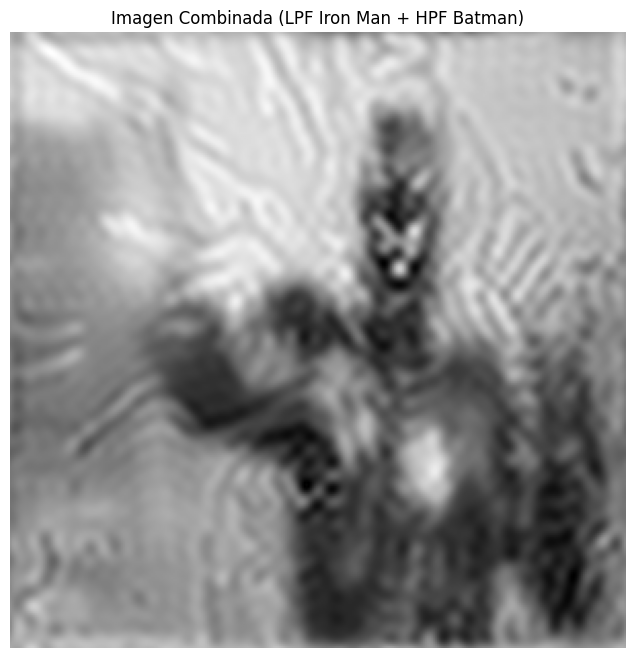

In [25]:
"""
Filtramos las imágenes y aplicamos la transformada inversa
para regresarlas al espacio de la imagen.
"""

# Aplicar filtros y combinar
combined = np.fft.ifft2(
    np.multiply(I1_fft, lpf_padded) +
    np.multiply(I2_fft, hpf_padded)
)

# Mostrar el resultado
plt.figure(figsize=(8, 8))
plt.imshow(np.abs(combined), cmap='gray')
plt.title("Imagen Combinada (LPF Iron Man + HPF Batman)")
plt.axis('off')
plt.show()

¿Cambia cuando se ve a diferentes distancias?
Cuando nos alejamos, normalmente se ve más la componente de baja frecuencia
Cuando nos acercamos, se ven más los detalles de alta frecuencia

PARTE 13: DETECCIÓN DE IMÁGENES BORROSAS

File ‘blurry.jpg’ already there; not retrieving.
No se pudo descargar la imagen, usando imagen suavizada de Lena
Media de la magnitud: 116.26
Umbral: 130
-> BORROSA


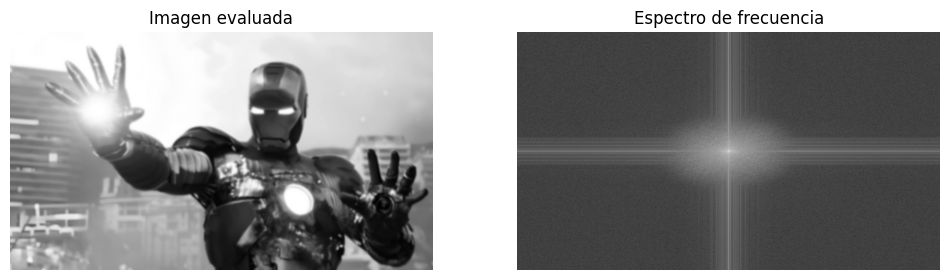

In [26]:
# Descargar imagen borrosa de ejemplo
!wget -nc "https://raw.githubusercontent.com/Jegovilla/cursoVR/main/blurry.jpg" -O blurry.jpg

# Cargar imagen
gray = cv2.imread("blurry.jpg", cv2.IMREAD_GRAYSCALE)
if gray is None:
    print("No se pudo descargar la imagen, usando imagen suavizada de Lena")
    gray = cv2.GaussianBlur(I, (15, 15), 0)

# Calcular FFT
fft = np.fft.fft2(gray)
fftshift = np.fft.fftshift(fft)

# Calcular la magnitud de la imagen y luego la media
magnitude = 20 * np.log(np.abs(fft) + 1)  # +1 para evitar log(0)
mean = np.mean(magnitude)

umbral = 130
print(f"Media de la magnitud: {mean:.2f}")
print(f"Umbral: {umbral}")

if mean <= umbral:
    print("-> BORROSA")
else:
    print("-> NÍTIDA")

# Mostrar imagen y su espectro
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Imagen evaluada")
axes[0].axis('off')

axes[1].imshow(np.log1p(np.abs(fftshift)), cmap='gray')
axes[1].set_title("Espectro de frecuencia")
axes[1].axis('off')
plt.show()

La imagen se considerará borrosa si la media de su magnitud está por debajo del umbral.
Las imágenes nítidas tienen altas frecuencias (valores altos en la magnitud)
Las imágenes borrosas tienen pocas altas frecuencias (valores bajos)